# Seed별 Phase 2 학습 비교 분석
두 seed의 Phase 2 로그를 파싱해서 H_s, H_p, argmax, d_commit 등을 비교합니다.

In [17]:
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ===== 경로 설정 =====
LOG_SEED_42 = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-None/42/20260311_144721/train_log_20260311_190442.log"
LOG_SEED_50 = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-None/50/20260311_163538/train_log_20260311_163538.log"

M = 8  # number of LCGs

In [18]:
def parse_log(filepath, M=8):
    """Phase 2 로그에서 routing/dcommit/auc 정보를 파싱"""
    data = defaultdict(list)
    
    # Regex patterns
    routing_pat = re.compile(
        r'\[ROUTING\] Step (\d+) \| Epoch (\d+) \|.*?'
        r'H_s=([\d.]+) H_p=([\d.]+) \|.*?'
        r'top1=([\d.]+)\(([\d.]+)~([\d.]+)\) \|.*?'
        r'p=\[([^\]]+)\] \|.*?'
        r'argmax=\[([^\]]+)\]'
    )
    
    dcommit_pat = re.compile(
        r'\[DCOMMIT\] Step (\d+) \| Epoch (\d+)'
    )
    dcommit_stats_pat = re.compile(
        r'd_commit: mean=([\d.]+), std=([\d.]+), min=([\d.]+), max=([\d.]+)'
    )
    gap_pat = re.compile(
        r'per-sample gap: mean=([\d.]+), min=([\d.]+), max=([\d.]+)'
    )
    logits_gap_pat = re.compile(
        r'logits gap: mean=([\d.]+), min=([\d.]+), max=([\d.]+)'
    )
    
    reg_pat = re.compile(
        r'\[REG\] LB=([\d.]+) \| Orth=([\d.]+) \| weighted_orth=([\d.]+) \| total_reg=([\d.]+)'
    )
    
    auc_pat = re.compile(
        r'\[Pre\]\[Epoch (\d+)/\d+\].*?'
        r'(Local|Global).*?Mean AUC ([\d.]+) \| Per-Source: \[([^\]]+)\]'
    )
    
    feat_range_pat = re.compile(r'feat range: ([\d.]+)')
    mcost_range_pat = re.compile(r'M_cost range: ([\d.]+)')
    
    current_dcommit_epoch = None
    
    with open(filepath, 'r') as f:
        for line in f:
            # Routing
            m = routing_pat.search(line)
            if m:
                step = int(m.group(1))
                epoch = int(m.group(2))
                h_s = float(m.group(3))
                h_p = float(m.group(4))
                top1_mean = float(m.group(5))
                top1_min = float(m.group(6))
                top1_max = float(m.group(7))
                p_vals = [float(x) for x in m.group(8).split()]
                argmax_vals = [int(x) for x in m.group(9).split()]
                
                data['step'].append(step)
                data['epoch'].append(epoch)
                data['h_s'].append(h_s)
                data['h_p'].append(h_p)
                data['top1_mean'].append(top1_mean)
                data['top1_min'].append(top1_min)
                data['top1_max'].append(top1_max)
                data['p_vals'].append(p_vals)
                data['argmax'].append(argmax_vals)
                continue
            
            # D_commit stats
            m = dcommit_stats_pat.search(line)
            if m:
                data['dc_mean'].append(float(m.group(1)))
                data['dc_std'].append(float(m.group(2)))
                data['dc_min'].append(float(m.group(3)))
                data['dc_max'].append(float(m.group(4)))
                continue
            
            # Per-sample gap
            m = gap_pat.search(line)
            if m:
                data['gap_mean'].append(float(m.group(1)))
                continue
            
            # Logits gap
            m = logits_gap_pat.search(line)
            if m:
                data['logits_gap_mean'].append(float(m.group(1)))
                continue
            
            # REG
            m = reg_pat.search(line)
            if m:
                data['lb_loss'].append(float(m.group(1)))
                data['orth_loss'].append(float(m.group(2)))
                data['total_reg'].append(float(m.group(4)))
                continue
            
            # AUC (Local/Global)
            m = auc_pat.search(line)
            if m:
                ep = int(m.group(1))
                branch = m.group(2)  # Local or Global
                mean_auc = float(m.group(3))
                per_source = [float(x.strip().strip("'")) for x in m.group(4).split(',')]
                key = f'auc_{branch.lower()}'
                data[f'{key}_epoch'].append(ep)
                data[f'{key}_mean'].append(mean_auc)
                data[f'{key}_per_source'].append(per_source)
                continue
            
            # Feat range
            m = feat_range_pat.search(line)
            if m:
                data['feat_range'].append(float(m.group(1)))
                continue
            
            # M_cost range
            m = mcost_range_pat.search(line)
            if m:
                data['mcost_range'].append(float(m.group(1)))
                continue
    
    return dict(data)

print("Parser defined.")

Parser defined.


In [19]:
# 파싱
d42 = parse_log(LOG_SEED_42, M)
d50 = parse_log(LOG_SEED_50, M)

print(f"Seed 42: {len(d42.get('step',[]))} routing entries, {len(d42.get('auc_global_epoch',[]))} AUC entries")
print(f"Seed 50: {len(d50.get('step',[]))} routing entries, {len(d50.get('auc_global_epoch',[]))} AUC entries")

Seed 42: 6 routing entries, 0 AUC entries
Seed 50: 364 routing entries, 0 AUC entries


In [20]:
def plot_comparison(d42, d50, key_y, ylabel, title, key_x='step', figsize=(12,4)):
    """두 seed의 특정 metric을 비교 플롯"""
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    if key_y in d42 and len(d42[key_y]) > 0:
        x42 = d42[key_x][:len(d42[key_y])] if key_x in d42 else range(len(d42[key_y]))
        ax.plot(x42, d42[key_y], label='Seed 42', alpha=0.8)
    
    if key_y in d50 and len(d50[key_y]) > 0:
        x50 = d50[key_x][:len(d50[key_y])] if key_x in d50 else range(len(d50[key_y]))
        ax.plot(x50, d50[key_y], label='Seed 50', alpha=0.8)
    
    ax.set_xlabel(key_x)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 1. H_s, H_p 비교 (Routing Entropy)

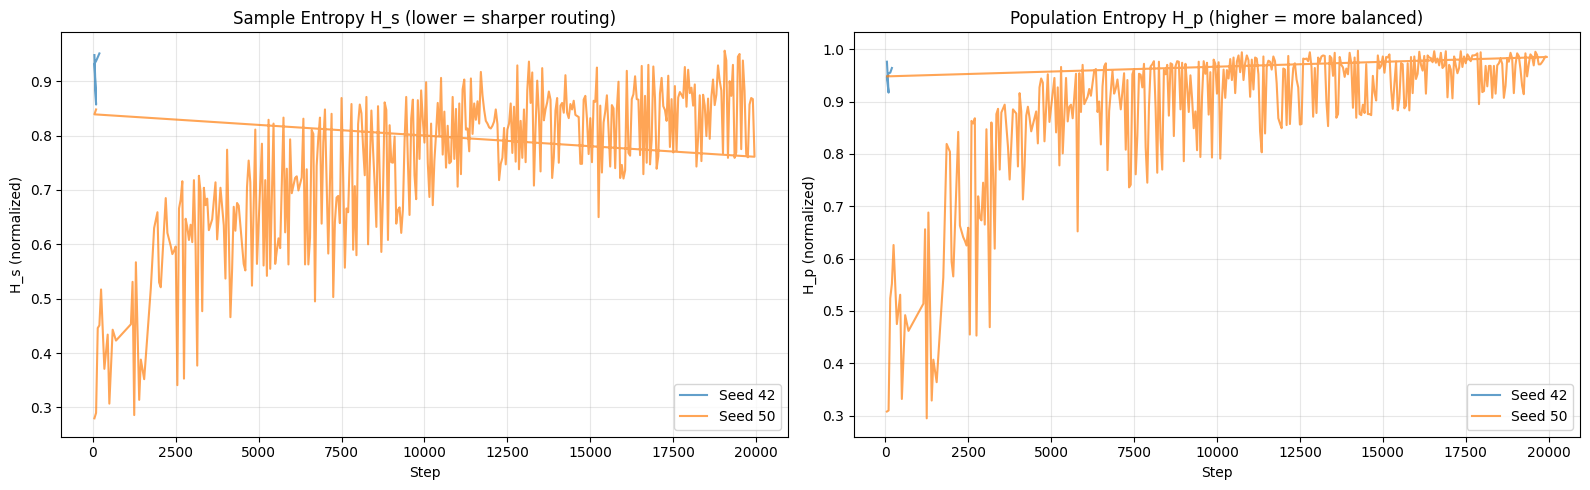

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# H_s (Sample entropy) - 낮을수록 sharp
if 'h_s' in d42: axes[0].plot(d42['step'], d42['h_s'], label='Seed 42', alpha=0.7)
if 'h_s' in d50: axes[0].plot(d50['step'], d50['h_s'], label='Seed 50', alpha=0.7)
axes[0].set_xlabel('Step'); axes[0].set_ylabel('H_s (normalized)')
axes[0].set_title('Sample Entropy H_s (lower = sharper routing)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# H_p (Population entropy) - 높을수록 balanced
if 'h_p' in d42: axes[1].plot(d42['step'], d42['h_p'], label='Seed 42', alpha=0.7)
if 'h_p' in d50: axes[1].plot(d50['step'], d50['h_p'], label='Seed 50', alpha=0.7)
axes[1].set_xlabel('Step'); axes[1].set_ylabel('H_p (normalized)')
axes[1].set_title('Population Entropy H_p (higher = more balanced)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Top1 Probability (Routing Sharpness)

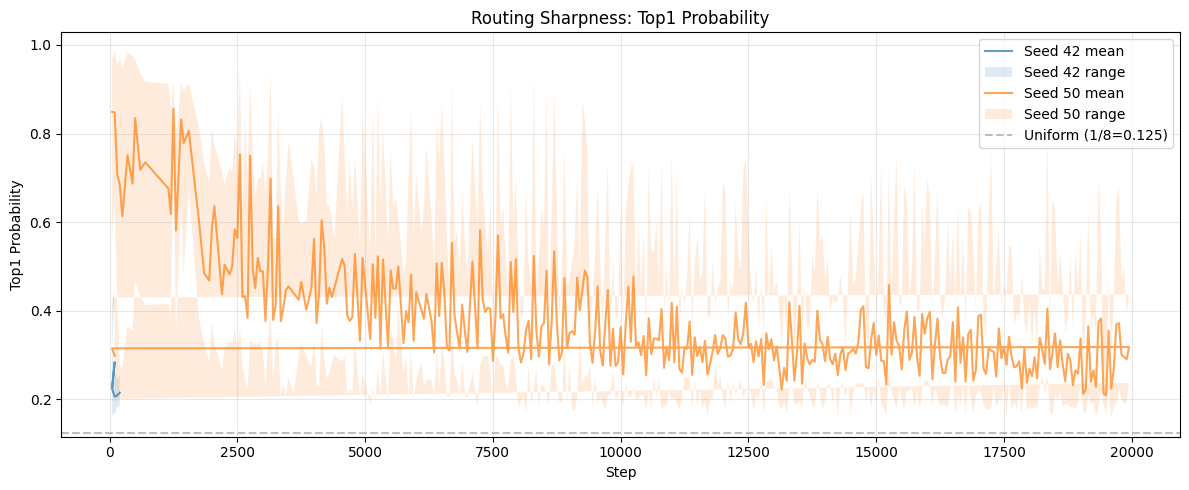

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

if 'top1_mean' in d42:
    ax.plot(d42['step'], d42['top1_mean'], label='Seed 42 mean', alpha=0.7)
    ax.fill_between(d42['step'], d42['top1_min'], d42['top1_max'], alpha=0.15, label='Seed 42 range')

if 'top1_mean' in d50:
    ax.plot(d50['step'], d50['top1_mean'], label='Seed 50 mean', alpha=0.7)
    ax.fill_between(d50['step'], d50['top1_min'], d50['top1_max'], alpha=0.15, label='Seed 50 range')

ax.axhline(y=1/M, color='gray', linestyle='--', alpha=0.5, label=f'Uniform (1/{M}={1/M:.3f})')
ax.set_xlabel('Step'); ax.set_ylabel('Top1 Probability')
ax.set_title('Routing Sharpness: Top1 Probability')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Per-LCG Argmax Count 추이 (LCG 활성도)

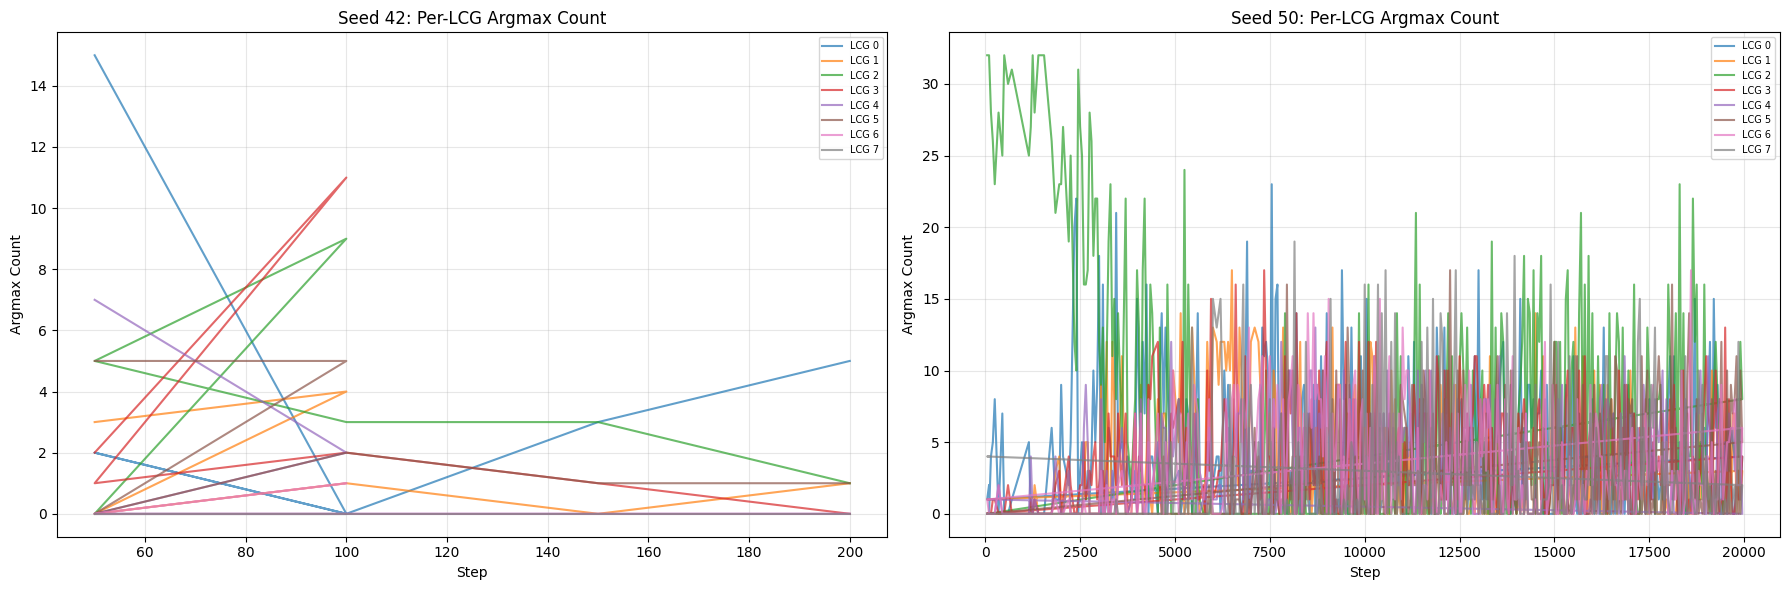

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, (data, seed_name) in enumerate([(d42, 'Seed 42'), (d50, 'Seed 50')]):
    if 'argmax' not in data or len(data['argmax']) == 0:
        continue
    argmax_arr = np.array(data['argmax'])  # [num_steps, M]
    steps = data['step'][:len(argmax_arr)]
    
    for lcg_i in range(M):
        axes[idx].plot(steps, argmax_arr[:, lcg_i], label=f'LCG {lcg_i}', alpha=0.7)
    
    axes[idx].set_xlabel('Step'); axes[idx].set_ylabel('Argmax Count')
    axes[idx].set_title(f'{seed_name}: Per-LCG Argmax Count')
    axes[idx].legend(loc='upper right', fontsize=7)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Population Distribution (p) 추이

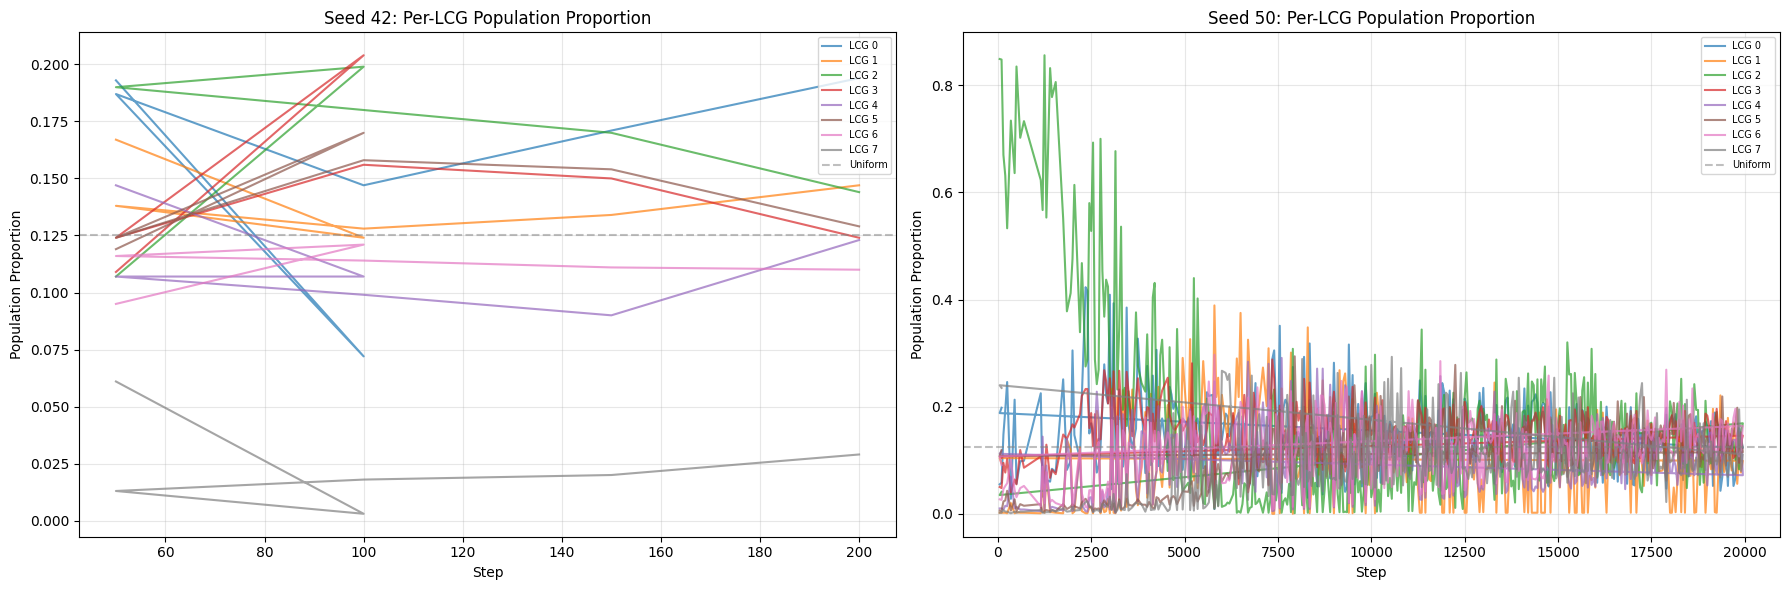

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, (data, seed_name) in enumerate([(d42, 'Seed 42'), (d50, 'Seed 50')]):
    if 'p_vals' not in data or len(data['p_vals']) == 0:
        continue
    p_arr = np.array(data['p_vals'])  # [num_steps, M]
    steps = data['step'][:len(p_arr)]
    
    for lcg_i in range(M):
        axes[idx].plot(steps, p_arr[:, lcg_i], label=f'LCG {lcg_i}', alpha=0.7)
    
    axes[idx].axhline(y=1/M, color='gray', linestyle='--', alpha=0.5, label=f'Uniform')
    axes[idx].set_xlabel('Step'); axes[idx].set_ylabel('Population Proportion')
    axes[idx].set_title(f'{seed_name}: Per-LCG Population Proportion')
    axes[idx].legend(loc='upper right', fontsize=7)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. D_commit 통계 비교

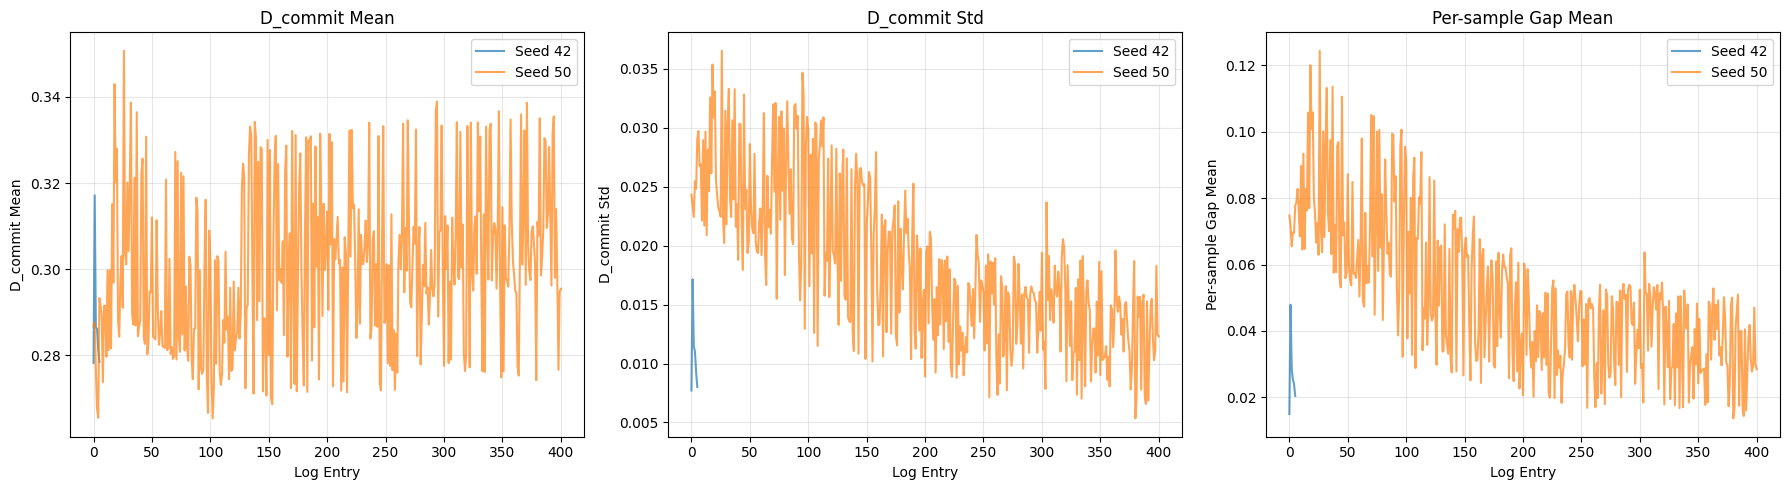

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# D_commit mean
plot_keys = [('dc_mean', 'D_commit Mean'), ('dc_std', 'D_commit Std'), ('gap_mean', 'Per-sample Gap Mean')]

for ax, (key, title) in zip(axes, plot_keys):
    if key in d42 and len(d42[key]) > 0:
        ax.plot(range(len(d42[key])), d42[key], label='Seed 42', alpha=0.7)
    if key in d50 and len(d50[key]) > 0:
        ax.plot(range(len(d50[key])), d50[key], label='Seed 50', alpha=0.7)
    ax.set_xlabel('Log Entry'); ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Logits Gap (routing 구별력)

In [27]:
# plot_comparison(d42, d50, 'logits_gap_mean', 'Logits Gap Mean', 
#                 'Logits Gap (higher = more discriminative routing)')

## 7. Regularization Loss 비교

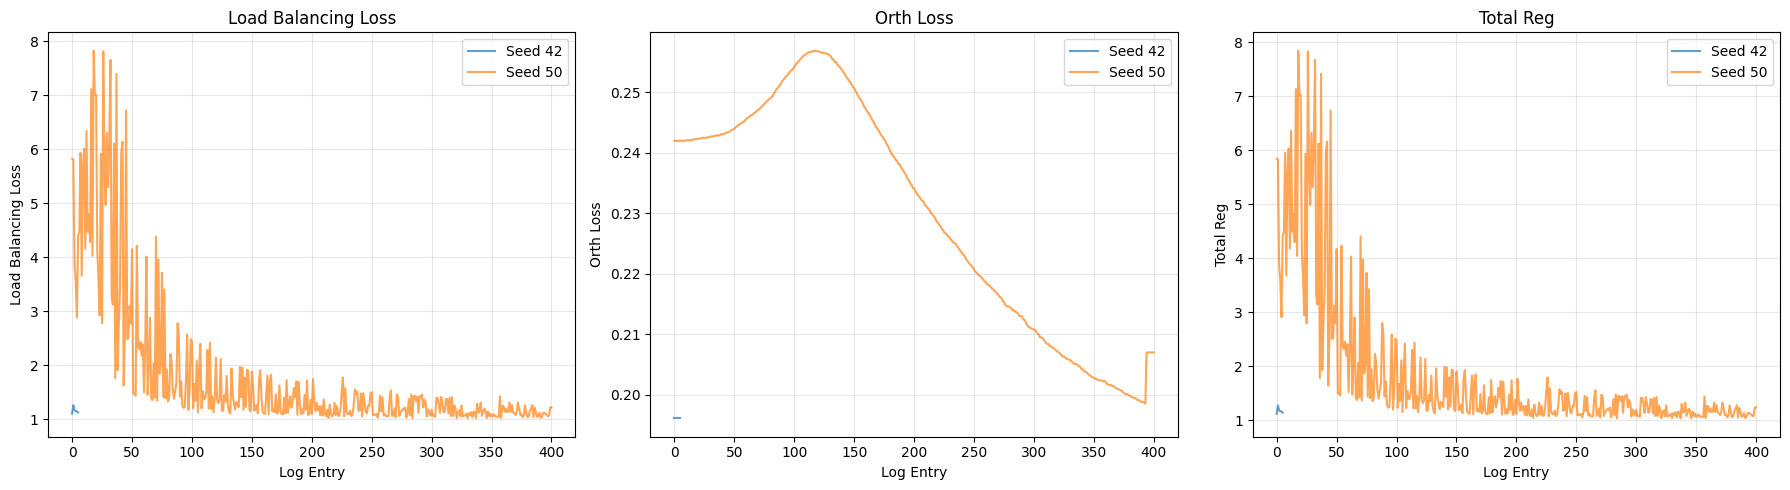

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (key, title) in zip(axes, [('lb_loss', 'Load Balancing Loss'), ('orth_loss', 'Orth Loss'), ('total_reg', 'Total Reg')]):
    if key in d42 and len(d42[key]) > 0:
        ax.plot(range(len(d42[key])), d42[key], label='Seed 42', alpha=0.7)
    if key in d50 and len(d50[key]) > 0:
        ax.plot(range(len(d50[key])), d50[key], label='Seed 50', alpha=0.7)
    ax.set_xlabel('Log Entry'); ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Source Val AUC 추이 (Global)

/tmp/ipykernel_3889198/963349170.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(); axes[0].grid(True, alpha=0.3)
/tmp/ipykernel_3889198/963349170.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(); axes[1].grid(True, alpha=0.3)


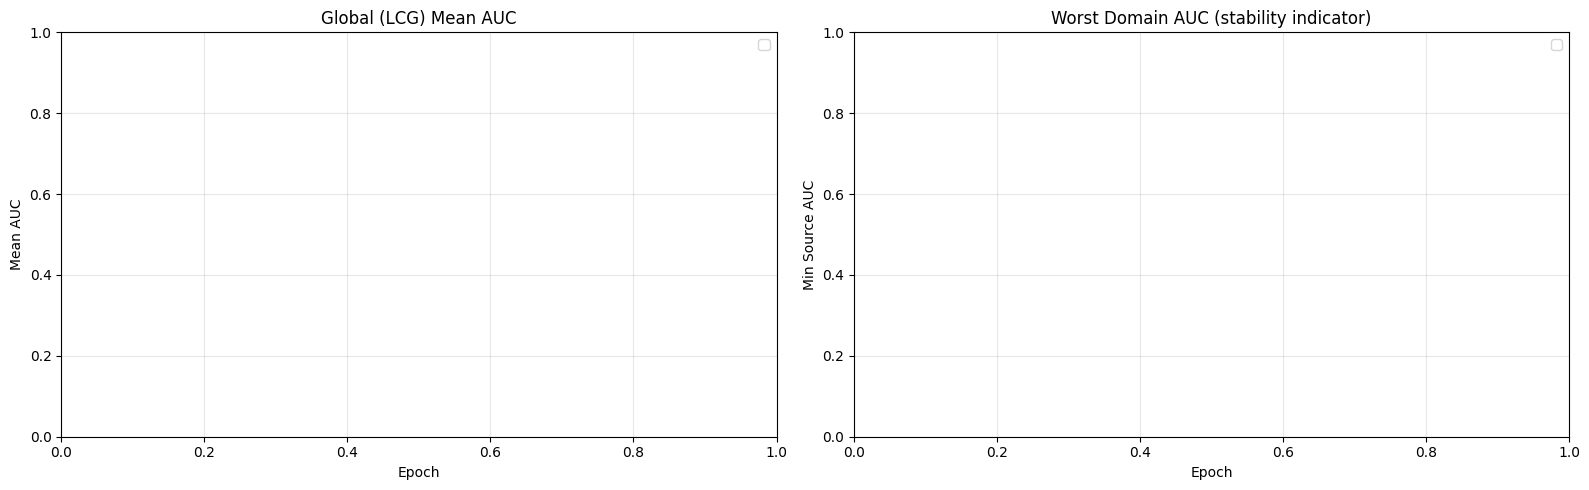

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Global Mean AUC
if 'auc_global_epoch' in d42 and len(d42['auc_global_mean']) > 0:
    axes[0].plot(d42['auc_global_epoch'], d42['auc_global_mean'], label='Seed 42', alpha=0.8)
if 'auc_global_epoch' in d50 and len(d50['auc_global_mean']) > 0:
    axes[0].plot(d50['auc_global_epoch'], d50['auc_global_mean'], label='Seed 50', alpha=0.8)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Mean AUC')
axes[0].set_title('Global (LCG) Mean AUC')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Per-source AUC for worst domain
for seed_data, seed_name in [(d42, 'Seed 42'), (d50, 'Seed 50')]:
    if 'auc_global_per_source' in seed_data and len(seed_data['auc_global_per_source']) > 0:
        per_src = np.array(seed_data['auc_global_per_source'])
        epochs = seed_data['auc_global_epoch'][:len(per_src)]
        min_auc = per_src.min(axis=1)
        axes[1].plot(epochs, min_auc, label=f'{seed_name} (worst domain)', alpha=0.8)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Min Source AUC')
axes[1].set_title('Worst Domain AUC (stability indicator)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Feat Range & M_cost Range (LCG 구별력)

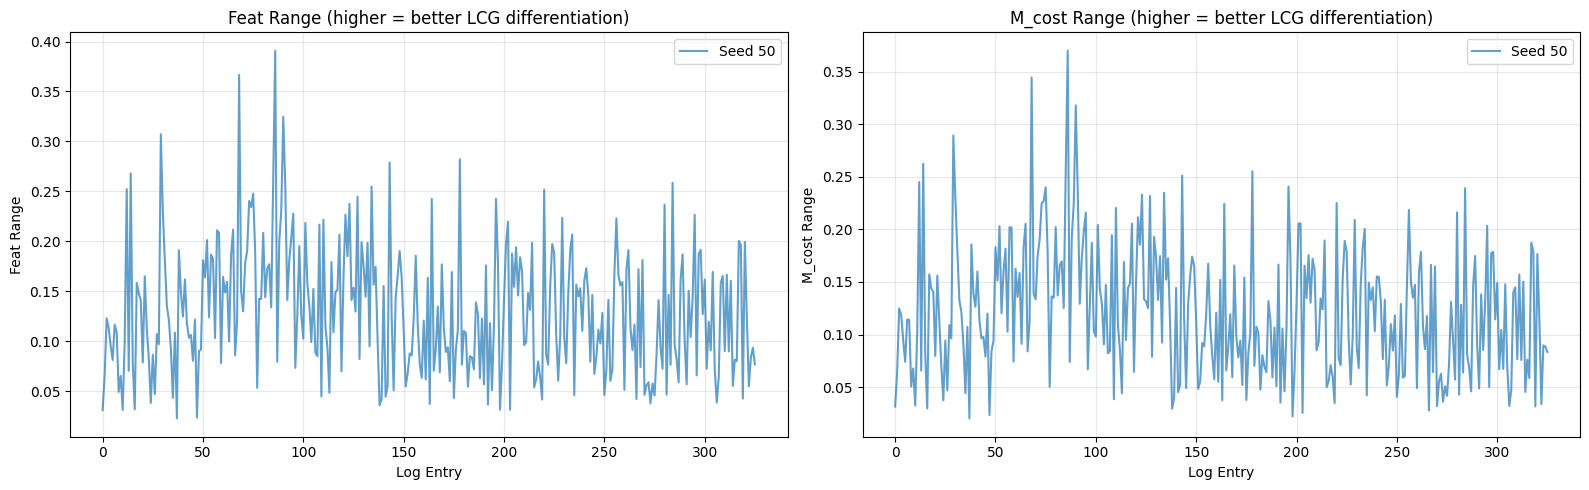

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (key, title) in zip(axes, [('feat_range', 'Feat Range'), ('mcost_range', 'M_cost Range')]):
    if key in d42 and len(d42[key]) > 0:
        ax.plot(range(len(d42[key])), d42[key], label='Seed 42', alpha=0.7)
    if key in d50 and len(d50[key]) > 0:
        ax.plot(range(len(d50[key])), d50[key], label='Seed 50', alpha=0.7)
    ax.set_xlabel('Log Entry'); ax.set_ylabel(title)
    ax.set_title(f'{title} (higher = better LCG differentiation)')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. 요약 통계

In [31]:
def summarize(data, name):
    print(f"\n{'='*50}")
    print(f"  {name} Summary")
    print(f"{'='*50}")
    
    if 'h_s' in data and len(data['h_s']) > 0:
        print(f"  H_s  : first={data['h_s'][0]:.3f}, last={data['h_s'][-1]:.3f}, min={min(data['h_s']):.3f}")
    if 'h_p' in data and len(data['h_p']) > 0:
        print(f"  H_p  : first={data['h_p'][0]:.3f}, last={data['h_p'][-1]:.3f}, max={max(data['h_p']):.3f}")
    if 'top1_mean' in data and len(data['top1_mean']) > 0:
        print(f"  Top1 : first={data['top1_mean'][0]:.3f}, last={data['top1_mean'][-1]:.3f}, max={max(data['top1_mean']):.3f}")
    if 'lb_loss' in data and len(data['lb_loss']) > 0:
        print(f"  LB   : first={data['lb_loss'][0]:.4f}, last={data['lb_loss'][-1]:.4f}")
    if 'gap_mean' in data and len(data['gap_mean']) > 0:
        print(f"  Gap  : first={data['gap_mean'][0]:.6f}, last={data['gap_mean'][-1]:.6f}")
    if 'logits_gap_mean' in data and len(data['logits_gap_mean']) > 0:
        print(f"  Logit: first={data['logits_gap_mean'][0]:.4f}, last={data['logits_gap_mean'][-1]:.4f}")
    if 'feat_range' in data and len(data['feat_range']) > 0:
        print(f"  FeatR: first={data['feat_range'][0]:.6f}, last={data['feat_range'][-1]:.6f}")
    if 'auc_global_mean' in data and len(data['auc_global_mean']) > 0:
        print(f"  AUC  : first={data['auc_global_mean'][0]:.4f}, best={max(data['auc_global_mean']):.4f}, last={data['auc_global_mean'][-1]:.4f}")
    
    # Dead LCG 분석 (마지막 10개 routing의 argmax)
    if 'argmax' in data and len(data['argmax']) >= 10:
        last_argmax = np.array(data['argmax'][-10:])
        total_per_lcg = last_argmax.sum(axis=0)
        dead = [i for i in range(len(total_per_lcg)) if total_per_lcg[i] == 0]
        print(f"  Dead LCGs (last 10 steps): {dead if dead else 'None'}")
        print(f"  LCG usage (last 10): {total_per_lcg}")

summarize(d42, 'Seed 42')
summarize(d50, 'Seed 50')


  Seed 42 Summary
  H_s  : first=0.948, last=0.951, min=0.857
  H_p  : first=0.976, last=0.964, max=0.976
  Top1 : first=0.226, last=0.215, max=0.284
  LB   : first=1.0994, last=1.1214
  Gap  : first=0.014959, last=0.020431
  Logit: first=0.2553, last=0.2290

  Seed 50 Summary
  H_s  : first=0.280, last=0.848, min=0.280
  H_p  : first=0.308, last=0.949, max=0.997
  Top1 : first=0.849, last=0.298, max=0.856
  LB   : first=5.8210, last=1.2174
  Gap  : first=0.074758, last=0.028441
  Logit: first=2.8055, last=0.2631
  FeatR: first=0.030953, last=0.076914
  Dead LCGs (last 10 steps): None
  LCG usage (last 10): [24 23 48 18 42 50 38 27]


In [32]:
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def parse_few_log(filepath, M=8):
    """Target adaptation (Few) 로그 파싱"""
    data = defaultdict(list)
    
    routing_pat = re.compile(
        r'\[ROUTING\] Step (\d+) \| Epoch (\d+) \|.*?'
        r'H_s=([\d.]+) H_p=([\d.]+) \|.*?'
        r'top1=([\d.]+)\(([\d.]+)~([\d.]+)\) \|.*?'
        r'p=\[([^\]]+)\] \|.*?'
        r'argmax=\[([^\]]+)\]'
    )
    dcommit_stats_pat = re.compile(
        r'd_commit: mean=([\d.]+), std=([\d.]+), min=([\d.]+), max=([\d.]+)'
    )
    gap_pat = re.compile(r'per-sample gap: mean=([\d.]+)')
    logits_gap_pat = re.compile(r'logits gap: mean=([\d.]+)')
    reg_pat = re.compile(r'\[REG\].*?total_reg=([\d.]+)')
    
    # Few adaptation AUC
    few_auc_pat = re.compile(
        r'\[Few\]\[Ep (\d+)/\d+\].*?\n.*?'
        r'\[Global\] AUC\s*:\s*([\d.]+) / ([\d.]+)'
    )
    # test final
    test_pat = re.compile(
        r'\[Test Final\].*?AUC: ([\d.]+).*?AUPRC: ([\d.]+).*?ACC: ([\d.]+)'
    )
    few_ep_pat = re.compile(
        r'\[Few-shot\]\[Ep (\d+)/\d+\] AUC=([\d.]+)'
    )

    with open(filepath, 'r') as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i]

        # Routing
        m = routing_pat.search(line)
        if m:
            data['step'].append(int(m.group(1)))
            data['epoch'].append(int(m.group(2)))
            data['h_s'].append(float(m.group(3)))
            data['h_p'].append(float(m.group(4)))
            data['top1_mean'].append(float(m.group(5)))
            p_vals = [float(x) for x in m.group(8).split()]
            argmax_vals = [int(x) for x in m.group(9).split()]
            data['p_vals'].append(p_vals)
            data['argmax'].append(argmax_vals)
            i += 1; continue

        # d_commit stats
        m = dcommit_stats_pat.search(line)
        if m:
            data['dc_mean'].append(float(m.group(1)))
            data['dc_std'].append(float(m.group(2)))
            i += 1; continue

        # per-sample gap
        m = gap_pat.search(line)
        if m:
            data['gap_mean'].append(float(m.group(1)))
            i += 1; continue

        # logits gap
        m = logits_gap_pat.search(line)
        if m:
            data['logits_gap_mean'].append(float(m.group(1)))
            i += 1; continue

        # REG
        m = reg_pat.search(line)
        if m:
            data['total_reg'].append(float(m.group(1)))
            i += 1; continue

        # Few AUC per epoch (2줄에 걸쳐있어서 다음줄까지 같이 파싱)
        if '[Few][Ep' in line and i + 1 < len(lines):
            ep_m = re.search(r'\[Few\]\[Ep (\d+)/\d+\]', line)
            auc_m = re.search(r'\[Global\] AUC\s*:\s*([\d.]+) / ([\d.]+)', lines[i+1] if i+1 < len(lines) else '')
            if ep_m and auc_m:
                data['few_epoch'].append(int(ep_m.group(1)))
                data['few_train_auc'].append(float(auc_m.group(1)))
                data['few_val_auc'].append(float(auc_m.group(2)))
            i += 1; continue

        # Test Final
        m = test_pat.search(line)
        if m:
            data['final_auc'] = float(m.group(1))
            data['final_auprc'] = float(m.group(2))
            data['final_acc'] = float(m.group(3))
            i += 1; continue

        # Few-shot episode summary
        m = few_ep_pat.search(line)
        if m:
            data['ep_auc'].append(float(m.group(2)))
            i += 1; continue

        i += 1

    return dict(data)


def plot_few_analysis(log_path, label="", M=8):
    d = parse_few_log(log_path, M=M)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Few-shot Adaptation Analysis: {label}', fontsize=13)

    # 1. Routing Entropy
    ax = axes[0, 0]
    if 'h_s' in d:
        ax.plot(d['h_s'], label='H_s (sample)', alpha=0.8)
        ax.plot(d['h_p'], label='H_p (population)', alpha=0.8)
        ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Max entropy')
        ax.set_title('Routing Entropy')
        ax.set_xlabel('Log step'); ax.legend()

    # 2. Top1 routing prob
    ax = axes[0, 1]
    if 'top1_mean' in d:
        ax.plot(d['top1_mean'], color='red', alpha=0.8)
        ax.axhline(1/M, color='gray', linestyle='--', alpha=0.5, label=f'Uniform (1/{M})')
        ax.set_title('Top1 Routing Prob (lower = more diverse)')
        ax.set_xlabel('Log step'); ax.legend()

    # 3. Per-LCG argmax count
    ax = axes[0, 2]
    if 'argmax' in d:
        argmax_arr = np.array(d['argmax'])
        for m in range(M):
            ax.plot(argmax_arr[:, m], label=f'LCG{m}', alpha=0.7)
        ax.set_title('Per-LCG Argmax Count')
        ax.set_xlabel('Log step'); ax.legend(fontsize=7, ncol=2)

    # 4. Val AUC curve (if exists)
    ax = axes[1, 0]
    if 'few_val_auc' in d and len(d['few_val_auc']) > 0:
        ax.plot(d['few_epoch'], d['few_val_auc'], label='Val AUC', color='blue')
        ax.plot(d['few_epoch'], d['few_train_auc'], label='Train AUC', color='orange', alpha=0.7)
        ax.set_title('AUC during Adaptation')
        ax.set_xlabel('Epoch'); ax.legend()
    else:
        ax.text(0.5, 0.5, 'No per-epoch AUC log', ha='center', va='center')
        ax.set_title('AUC during Adaptation')

    # 5. d_commit mean & std
    ax = axes[1, 1]
    if 'dc_mean' in d:
        ax.plot(d['dc_mean'], label='d_commit mean', color='purple')
        ax.plot(d['dc_std'], label='d_commit std', color='green', alpha=0.7)
        ax.set_title('d_commit Statistics')
        ax.set_xlabel('Log step'); ax.legend()

    # 6. Logits gap
    ax = axes[1, 2]
    if 'logits_gap_mean' in d:
        ax.plot(d['logits_gap_mean'], color='teal')
        ax.set_title('Logits Gap Mean (higher = sharper routing)')
        ax.set_xlabel('Log step')

    plt.tight_layout()
    plt.savefig(f'few_analysis_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Summary
    print(f"\n=== [{label}] Summary ===")
    if 'final_auc' in d:
        print(f"  Final Test AUC  : {d['final_auc']:.4f}")
        print(f"  Final Test AUPRC: {d['final_auprc']:.4f}")
        print(f"  Final Test ACC  : {d['final_acc']:.4f}")
    if 'ep_auc' in d:
        print(f"  Episode AUCs    : {[f'{x:.4f}' for x in d['ep_auc']]}")
    if 'h_s' in d:
        print(f"  H_s (mean/final): {np.mean(d['h_s']):.3f} / {d['h_s'][-1]:.3f}")
        print(f"  Top1 (mean/final): {np.mean(d['top1_mean']):.3f} / {d['top1_mean'][-1]:.3f}")

    return d

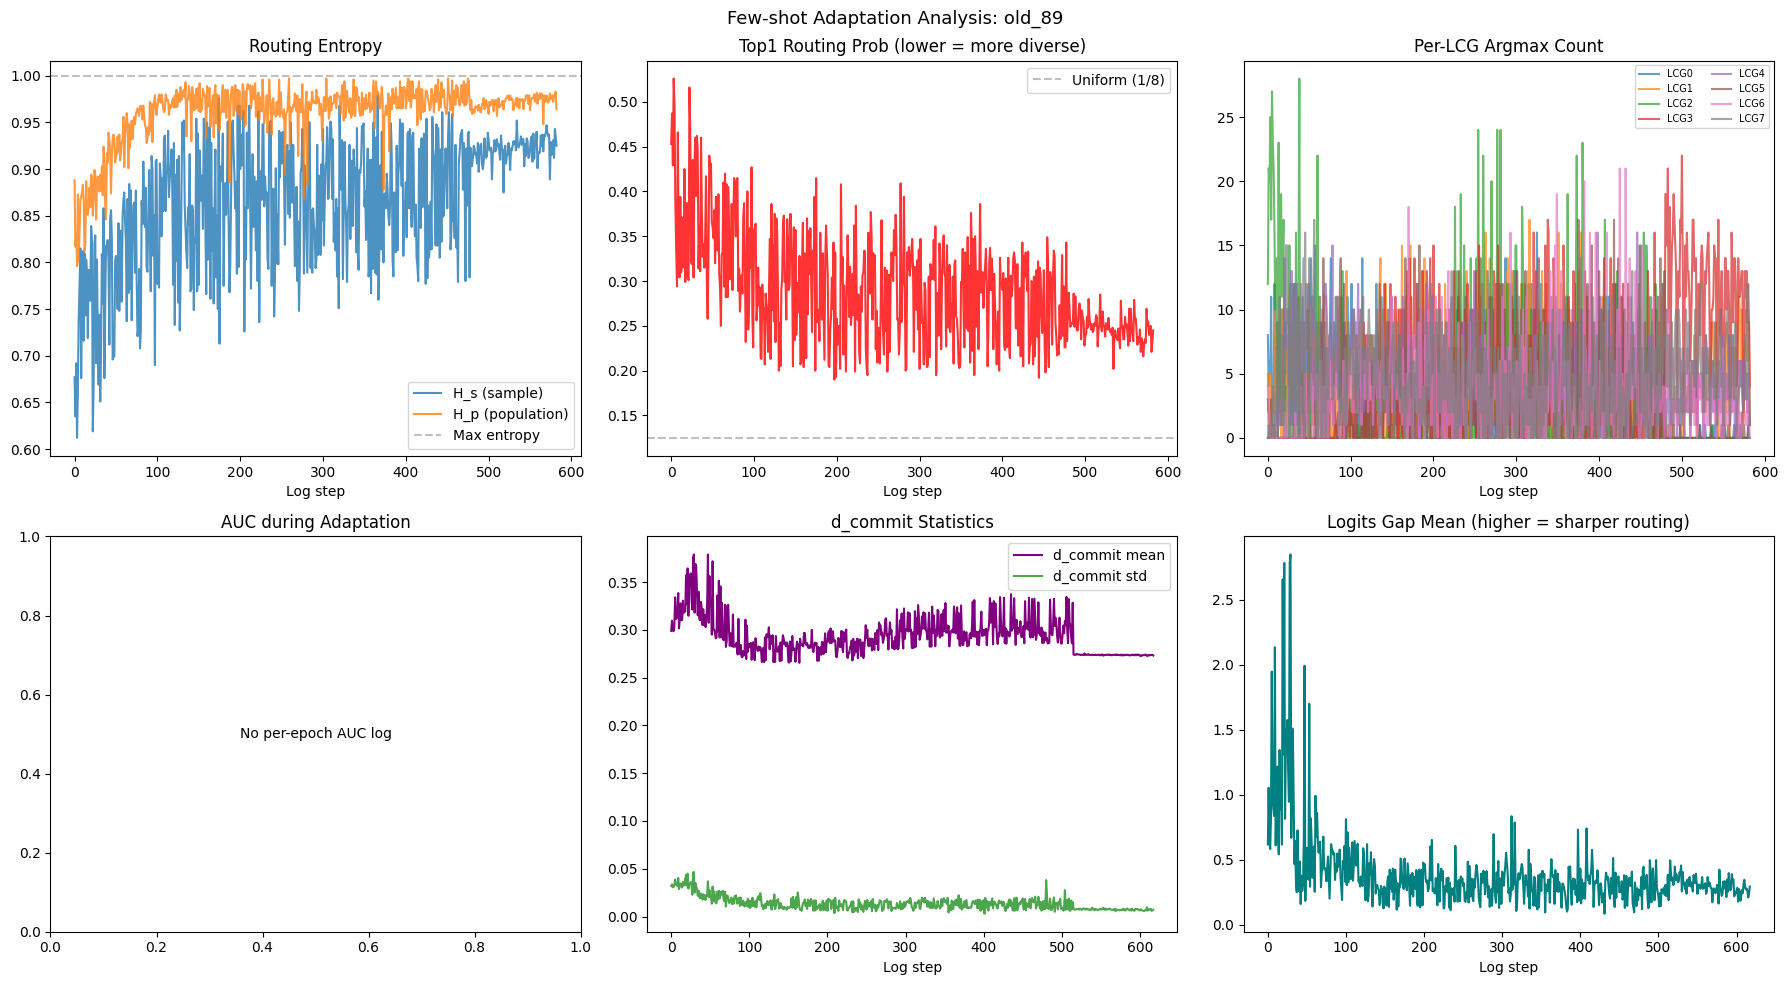


=== [old_89] Summary ===
  Final Test AUC  : 0.8949
  Final Test AUPRC: 0.9166
  Final Test ACC  : 0.8424
  Episode AUCs    : ['0.8949']
  H_s (mean/final): 0.864 / 0.925
  Top1 (mean/final): 0.289 / 0.245


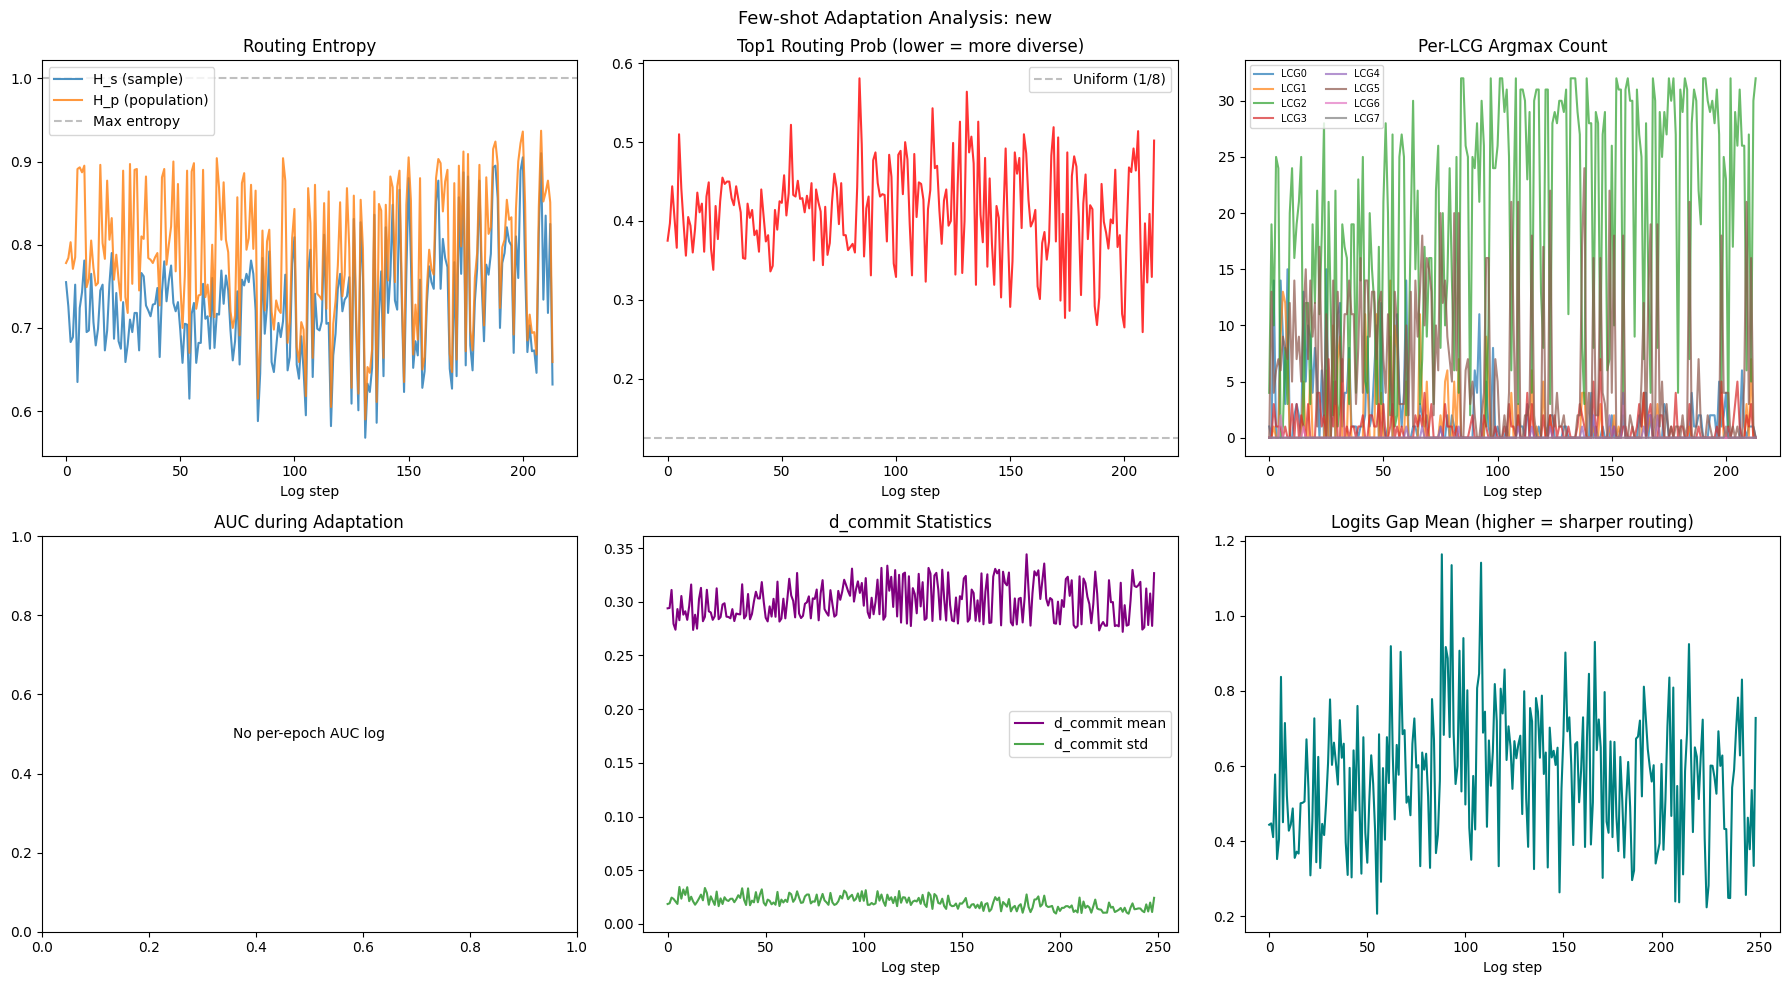


=== [new] Summary ===
  Final Test AUC  : 0.7498
  Final Test AUPRC: 0.8103
  Final Test ACC  : 0.6841
  Episode AUCs    : ['0.7498']
  H_s (mean/final): 0.729 / 0.632
  Top1 (mean/final): 0.411 / 0.502


In [34]:
d_old = plot_few_analysis(
    "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-XTFORMER_EVALUATION100/50/20260225_221853/train_log_20260225_221853.log", 
    label="old_89"
)
#"/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-XTFORMER_EVALUATION100/50/20260225_221853/train_log_20260225_221853.log", 
# new 버전
d_new = plot_few_analysis(
    "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-1_AY/42/20260313_131439/train_log_20260313_131439.log",
    label="new"
)